# Step 3: Feature Extraction

Tujuan: Mengubah teks menjadi representasi numerik yang bisa digunakan oleh model ML.

**Metode untuk Text Categorization:**
- **TFIDF** (ngram_range=(1,2), max_features=50000) — Direkomendasikan
- Word Embeddings — Untuk deep learning (opsional)

In [7]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data Hasil Preprocessing

In [8]:
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f'Jumlah data: {len(df)}')
print(f'\nDistribusi label:')
print(df['airline_sentiment'].value_counts())
print(f'\nContoh clean text:')
print(df['clean_text'].head(3).values)

Jumlah data: 14640

Distribusi label:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Contoh clean text:
['what said' 'plus youve added commercials to the experience tacky'
 'i didnt today must mean i need to take another trip']


**Hasil:**

Data dari preprocessing berhasil diload. 3 contoh clean text:
- `what said` — sangat pendek (neutral)
- `plus youve added commercials to the experience tacky` — positive
- `i didnt today must mean i need to take another trip` — neutral

Distribusi label tetap: negative 9.178, neutral 3.099, positive 2.363.

## 2. Encode Label

In [9]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['airline_sentiment'])

print('Label mapping:')
for i, label in enumerate(le.classes_):
    print(f'  {label} -> {i}')

y = df['label'].values

Label mapping:
  negative -> 0
  neutral -> 1
  positive -> 2


**Hasil:**

| Label | Encoding |
|-------|----------|
| negative | 0 |
| neutral | 1 |
| positive | 2 |

Label encoder mengubah teks label menjadi numerik. Mapping ini akan disimpan untuk inverse_transform saat evaluasi.

## 3. TFIDF Vectorization

In [10]:
# Untuk Text Categorization: ngram_range=(1,2), max_features=50000
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(df['clean_text'])

print(f'Matriks TF-IDF berhasil dibuat!')
print(f'Shape: {X.shape}')
print(f'Jumlah dokumen: {X.shape[0]}')
print(f'Jumlah fitur (kata/bigram): {X.shape[1]}')

Matriks TF-IDF berhasil dibuat!
Shape: (14640, 27780)
Jumlah dokumen: 14640
Jumlah fitur (kata/bigram): 27780


**Hasil:**

| Info | Nilai |
|------|-------|
| Jumlah dokumen | 14.640 |
| Jumlah fitur | 27.780 |
| Tipe matriks | Sparse (efisien memori) |

**Parameter TFIDF:**
- `ngram_range=(1,2)` — unigram + bigram (contoh: "not good" = 1 fitur)
- `max_features=50000` — batas maksimum, tapi hanya 27.780 yang lolos
- `sublinear_tf=True` — 1 + log(tf) agar skor TF tinggi tidak mendominasi
- `min_df=2` — kata harus muncul minimal 2 kali
- `max_df=0.95` — kata yang muncul di >95% dokumen diabaikan

Fitur sebanyak 27.780 cukup besar — bisa direduksi dengan feature selection jika diperlukan.

## 4. Analisis Fitur TFIDF

In [11]:
# Top fitur berdasarkan rata-rata TF-IDF score
feature_names = tfidf.get_feature_names_out()
mean_tfidf = np.array(X.mean(axis=0)).flatten()

top_indices = mean_tfidf.argsort()[-20:][::-1]
top_features = [(feature_names[i], mean_tfidf[i]) for i in top_indices]

print('=== Top 20 Fitur berdasarkan rata-rata TF-IDF ===')
for word, score in top_features:
    print(f'{word:30s} {score:.6f}')

=== Top 20 Fitur berdasarkan rata-rata TF-IDF ===
to                             0.029356
the                            0.025256
you                            0.023270
for                            0.019865
flight                         0.019799
on                             0.019543
and                            0.018083
my                             0.017012
is                             0.016352
in                             0.014440
thanks                         0.013780
of                             0.012886
it                             0.012334
me                             0.012274
your                           0.011586
have                           0.010992
not                            0.010550
was                            0.010441
with                           0.010430
no                             0.010191


**Hasil:**

Top 10 fitur berdasarkan rata-rata TFIDF score:

| Rank | Fitur | Skor |
|------|-------|------|
| 1 | to | 0.029356 |
| 2 | the | 0.025256 |
| 3 | you | 0.023270 |
| 4 | for | 0.019865 |
| 5 | **flight** | 0.019799 |
| 6 | on | 0.019543 |
| 7 | and | 0.018083 |
| 8 | my | 0.017012 |
| 9 | is | 0.016352 |
| 10 | in | 0.014440 |

**Observasi:**
- Top fitur masih didominasi **kata umum** (to, the, you, for) — stop words
- **"flight"** di rank 5 — kata khas domain airline
- **"thanks"** di rank 11 — indikator sentimen positif
- **"not"** dan **"no"** di rank 17 dan 20 — penting untuk negasi sentiment

Stop words tidak dihapus karena penting untuk sentiment ("not good" berbeda dengan "good").

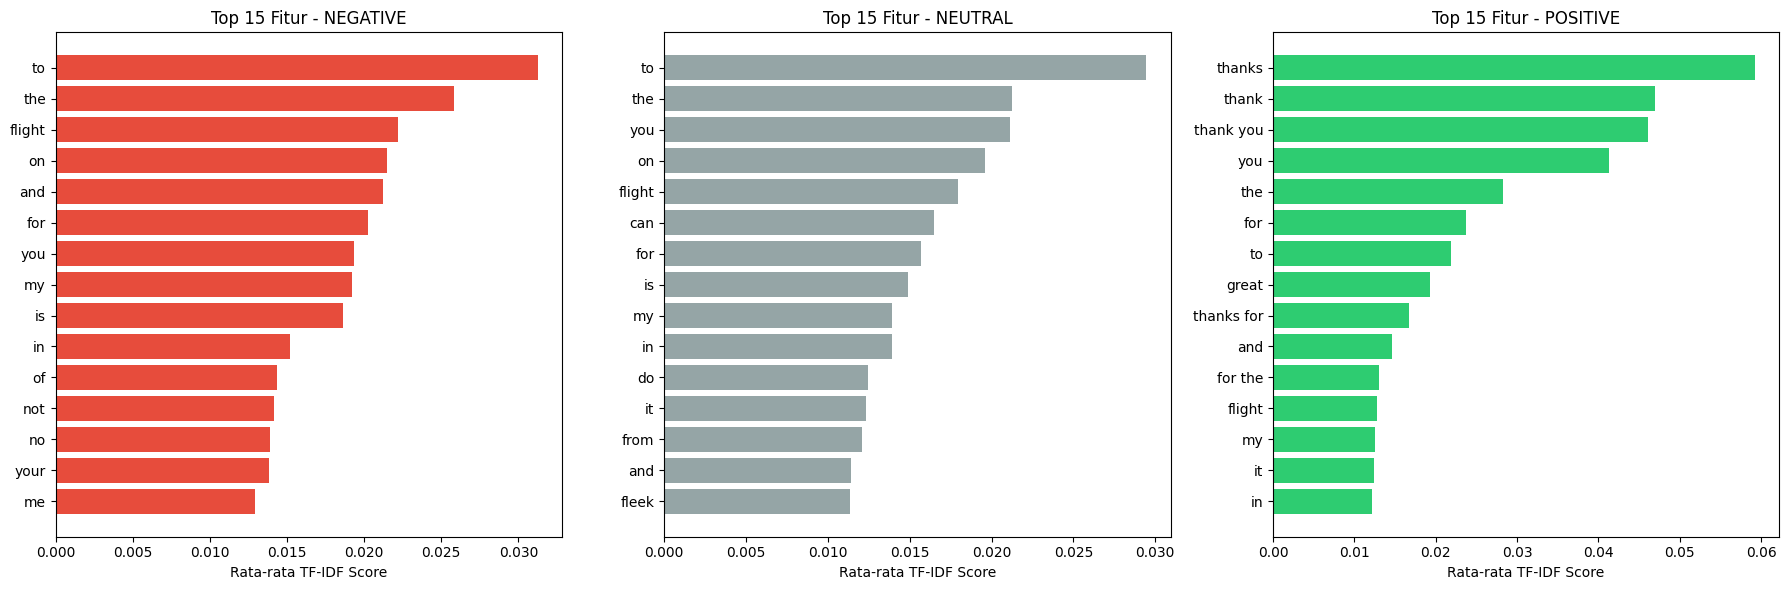

In [12]:
# Top fitur per kelas
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (sent, color) in enumerate(zip(['negative', 'neutral', 'positive'], ['#e74c3c', '#95a5a6', '#2ecc71'])):
    mask = (df['airline_sentiment'] == sent).values
    X_class = X[mask]
    mean_class = np.array(X_class.mean(axis=0)).flatten()
    top_idx = mean_class.argsort()[-15:][::-1]
    
    words = [feature_names[i] for i in top_idx]
    scores = [mean_class[i] for i in top_idx]
    
    axes[idx].barh(words[::-1], scores[::-1], color=color)
    axes[idx].set_title(f'Top 15 Fitur - {sent.upper()}', fontsize=12)
    axes[idx].set_xlabel('Rata-rata TF-IDF Score')

plt.tight_layout()
plt.savefig('../images/tfidf_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

**Hasil:**

Grafik top 15 fitur per kelas sentimen:

- **NEGATIVE** — fitur dominan: flight, service, time, bag, hold, hour, customer, call (keluhan)
- **NEUTRAL** — fitur netral/informatif: flight, airline, plane, get, would, http
- **POSITIVE** — fitur pujian: thanks, thank, great, love, best, amazing, awesome

**Insight:**
- "flight" muncul di semua kelas — tidak terlalu diskriminatif
- "thanks" dan "thank" spesifik untuk kelas positif
- "service" dan "customer" lebih dominan di kelas negatif (keluhan service)
- "http" muncul di neutral — link masih tersisa setelah preprocessing

## 5. Simpan Hasil Feature Extraction

In [13]:
import joblib
from scipy import sparse

# Simpan TF-IDF vectorizer dan label encoder
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
joblib.dump(le, '../models/label_encoder.pkl')

# Simpan data yang sudah diekstrak fiturnya
sparse.save_npz('../data/processed/X_tfidf.npz', X)
np.save('../data/processed/y_labels.npy', y)

print('Semua file tersimpan!')
print(f'  - models/tfidf_vectorizer.pkl')
print(f'  - models/label_encoder.pkl')
print(f'  - data/processed/X_tfidf.npz')
print(f'  - data/processed/y_labels.npy')

Semua file tersimpan!
  - models/tfidf_vectorizer.pkl
  - models/label_encoder.pkl
  - data/processed/X_tfidf.npz
  - data/processed/y_labels.npy


**Hasil:**

4 file tersimpan:

| File | Fungsi |
|------|--------|
| `models/tfidf_vectorizer.pkl` | TFIDF vectorizer (untuk transform data baru) |
| `models/label_encoder.pkl` | Label encoder (untuk inverse transform) |
| `data/processed/X_tfidf.npz` | Matriks fitur sparse (14640 x 27780) |
| `data/processed/y_labels.npy` | Array label numerik (14640) |

File ini akan digunakan di notebook berikutnya (`04_modeling.ipynb`).

## Ringkasan Feature Extraction

### Parameter TFIDF:
- **ngram_range:** (1, 2) — kata tunggal + pasangan kata
- **max_features:** 50.000 (yang lolos: 27.780)
- **sublinear_tf:** True — 1 + log(tf)
- **min_df:** 2 — minimal muncul 2 kali
- **max_df:** 0.95 — maksimal di 95% dokumen

### Hasil:
- Matriks fitur: **14.640 dokumen x 27.780 fitur** (sparse)
- Top fitur global: to, the, you, for, **flight**, on, and, my, is, in
- Top fitur negatif: flight, service, time, bag, hold, hour
- Top fitur positif: thanks, thank, great, love, best, amazing

### File Output:
- `models/tfidf_vectorizer.pkl` — TFIDF vectorizer
- `models/label_encoder.pkl` — Label encoder
- `data/processed/X_tfidf.npz` — Matriks fitur (sparse)
- `data/processed/y_labels.npy` — Label numerik

**Lanjut ke notebook berikutnya: `04_modeling.ipynb`**